# 1. 학습된 모델 저장

- 학습이 완료된 모델을 파일로 저장하여, 이후 추가 학습이나 예측 서비스에 사용할 수 있도록 한다.
- 파이토치(PyTorch)는 **모델의 파라미터만 저장**하는 방법과 **모델의 구조와 파라미터를 모두 저장**하는 두 가지 방식을 제공한다.
- 저장 함수
  - `torch.save(저장할 객체, 저장 경로)`
- 보통 저장 파일의 확장자는 `.pt`나 `.pth`를 사용한다.

## 1.1 모델 전체 저장 및 불러오기

- 저장하기
  - `torch.save(model, 저장 경로)`
- 불러오기
  - `load_model = torch.load(저장 경로)`
- 모델 저장 시 **피클(pickle)**을 사용해 직렬화되므로, 모델을 불러오는 실행 환경에도 저장할 때 사용한 클래스 정의가 필요하다.


## 1.2 모델의 파라미터만 저장

-   모델을 구성하는 파라미터만 저장한다.
-   모델의 구조는 저장하지 않기 때문에 불러올 때 **모델을 먼저 생성하고 생성한 모델에 불러온 파라미터를 덮어씌운다.**
-   모델의 파라미터는 **state_dict** 형식으로 저장한다.

### 1.2.1 state_dict

-   모델의 파라미터 Tensor들을 레이어 단위별로 나누어 저장한 Ordered Dictionary (OrderedDict)
-   `모델객체.state_dict()` 메소드를 이용해 조회한다.
-   모델의 state_dict을 조회 후 저장한다.
    -   `torch.save(model.state_dict(), "저장경로")`
-   생성된 모델에 읽어온 state_dict를 덮어씌운다.
    -   `new_model.load_state_dict(torch.load("state_dict저장경로"))`

\* ordered dict는 list 와 tuple을 사용하여 만든다.


## 1.3 Checkpoint 저장 및 불러오기

- 학습이 끝나지 않은 모델을 저장하고, 나중에 이어서 학습시키려면 모델의 구조와 파라미터뿐만 아니라 optimizer, loss 함수 등 학습에 필요한 객체들도 함께 저장해야 한다.
- 딕셔너리(Dictionary)에 저장하려는 값들을 key-value 쌍으로 구성하여 `torch.save()`를 이용해 저장한다.

```python
# 저장
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss
}, "저장경로")

# 불러오기
model = MyModel()
optimizer = optim.Adam(model.parameters())

# 불러온 checkpoint를 이용해 이전 학습 상태 복원
checkpoint = torch.load("저장경로")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
```

In [57]:
# 간단한 모델 정의
import torch
import torch.nn as nn

class MyModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(3, 4) # 3 X 4 + 4 
        self.lr2 = nn.Linear(4, 2)
        self.relu = nn.ReLU() # activation함수->파라미터가 없는 단순 계산함수. relu(X) = max(X, 0)
    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        return X

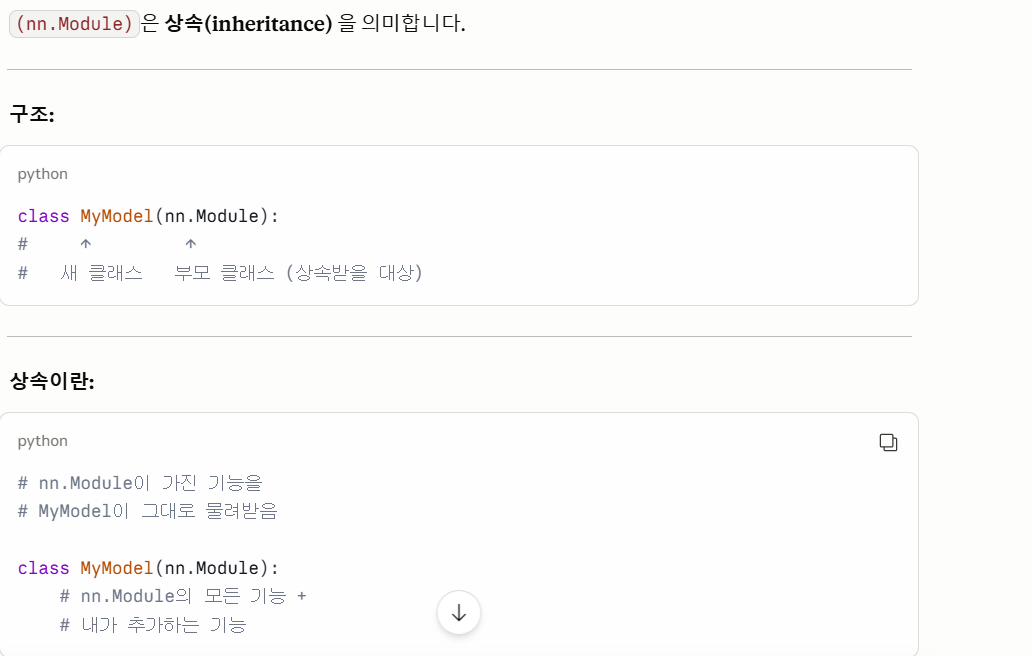

In [58]:
# 모델 생성성
model = MyModel()
model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [59]:
################################################
#  모델에 Layer들을 조회. 모델.instance변수명
################################################
lr_layer = model.lr1
lr_layer

Linear(in_features=3, out_features=4, bias=True)

In [60]:
################################################
#  Layer의 파라미터(weight/bias) 조회
################################################
lr1_weight = lr_layer.weight
lr1_bias = lr_layer.bias

In [61]:
lr1_weight

Parameter containing:
tensor([[ 0.0780, -0.2123,  0.5191],
        [ 0.2988,  0.1611, -0.3182],
        [ 0.5624,  0.3480,  0.2507],
        [ 0.3263, -0.4297,  0.2156]], requires_grad=True)

In [62]:
lr1_bias

Parameter containing:
tensor([ 0.2305,  0.3276, -0.2739, -0.4201], requires_grad=True)

In [63]:
import os
os.makedirs("saved_models", exist_ok=True)

In [64]:
################################################
#  모델을 저장
################################################
torch.save(model, "saved_models/my_model.pt")

In [65]:
################################################
#  저장된 모델 Load
################################################
load_model = torch.load("saved_models/my_model.pt", weights_only=False)

In [66]:
load_model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [67]:
load_model.lr1.weight

Parameter containing:
tensor([[ 0.0780, -0.2123,  0.5191],
        [ 0.2988,  0.1611, -0.3182],
        [ 0.5624,  0.3480,  0.2507],
        [ 0.3263, -0.4297,  0.2156]], requires_grad=True)

In [68]:
######################################################
# 모델의 파라미터들(weight들, bias들)만 저장/불러오기
######################################################
state_dict = model.state_dict()
state_dict

OrderedDict([('lr1.weight',
              tensor([[ 0.0780, -0.2123,  0.5191],
                      [ 0.2988,  0.1611, -0.3182],
                      [ 0.5624,  0.3480,  0.2507],
                      [ 0.3263, -0.4297,  0.2156]])),
             ('lr1.bias', tensor([ 0.2305,  0.3276, -0.2739, -0.4201])),
             ('lr2.weight',
              tensor([[-0.0998,  0.3164, -0.0843, -0.3239],
                      [-0.4076, -0.1040, -0.0301,  0.3963]])),
             ('lr2.bias', tensor([-0.4261, -0.4747]))])

In [69]:
state_dict.keys()

odict_keys(['lr1.weight', 'lr1.bias', 'lr2.weight', 'lr2.bias'])

In [70]:
state_dict.values()

odict_values([tensor([[ 0.0780, -0.2123,  0.5191],
        [ 0.2988,  0.1611, -0.3182],
        [ 0.5624,  0.3480,  0.2507],
        [ 0.3263, -0.4297,  0.2156]]), tensor([ 0.2305,  0.3276, -0.2739, -0.4201]), tensor([[-0.0998,  0.3164, -0.0843, -0.3239],
        [-0.4076, -0.1040, -0.0301,  0.3963]]), tensor([-0.4261, -0.4747])])

In [71]:
###################
# state_dict 저장
################### 

torch.save(state_dict, "saved_models/my_model_parameter.pt")

In [72]:
#####################
# state_dict load
#####################
sd = torch.load("saved_models/my_model_parameter.pt") # weight_only=True(default)

In [73]:
# load한 state_dict를 모델 파라미터에 적용(덮어 씌운다.)
new_model = MyModel() 
new_model.state_dict() # random으로 생성된 리턴값

OrderedDict([('lr1.weight',
              tensor([[ 0.4978, -0.1475,  0.3816],
                      [-0.0741, -0.4724, -0.4404],
                      [-0.2245,  0.2298, -0.4277],
                      [ 0.4650,  0.1542, -0.1233]])),
             ('lr1.bias', tensor([ 0.4925, -0.1683, -0.3272, -0.3374])),
             ('lr2.weight',
              tensor([[-0.2301, -0.3728,  0.3668, -0.2902],
                      [ 0.4402,  0.3536,  0.4783, -0.4257]])),
             ('lr2.bias', tensor([ 0.0467, -0.4766]))])

In [74]:
new_model.load_state_dict(sd)

<All keys matched successfully>

In [75]:
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[ 0.0780, -0.2123,  0.5191],
                      [ 0.2988,  0.1611, -0.3182],
                      [ 0.5624,  0.3480,  0.2507],
                      [ 0.3263, -0.4297,  0.2156]])),
             ('lr1.bias', tensor([ 0.2305,  0.3276, -0.2739, -0.4201])),
             ('lr2.weight',
              tensor([[-0.0998,  0.3164, -0.0843, -0.3239],
                      [-0.4076, -0.1040, -0.0301,  0.3963]])),
             ('lr2.bias', tensor([-0.4261, -0.4747]))])

In [76]:
# 가상환경에서 torchinfo 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
! uv pip install torchinfo

Checked 1 package in 3ms


In [77]:
# 일반환경에서 torchinfo 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
# ! pip install torchinfo

In [78]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            16
├─Linear: 1-2                            10
├─ReLU: 1-3                              --
Total params: 26
Trainable params: 26
Non-trainable params: 0

In [79]:
# input data 의 shape을 지정하면 각 Layer의 output shape을 출력한다.
summary(model, (100, 3))

# self.lr1 = nn.Linear(3, 4) self.lr2 = nn.Linear(4, 2) (100, 3)의 3과 (3, 4)의 3이 일치해야 된다

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 2]                  --
├─Linear: 1-1                            [100, 4]                  16
├─ReLU: 1-2                              [100, 4]                  --
├─Linear: 1-3                            [100, 2]                  10
Total params: 26
Trainable params: 26
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

# 2. 문제 유형별 MLP 네트워크
- 해결하려는 문제 유형에 따라 출력 Layer의 구조가 바뀐다.
- 딥러닝 구조에서 **Feature를 추출하는 Layer 들을 Backbone** 이라고 하고 **추론하는 Layer들을 Head** 라고 한다. 


> - MLP(Multi Layer Perceptron), DNN(Deep Neural Network), ANN(Artificial Neural Network)
>     -   Fully Connected Layer(nn.Linear)로 구성된 딥러닝 모델
>     -   input feature들 모두에 대응하는 weight들(가중치)을 사용한다.
> 

## 2.1 Boston Housing Dataset - **Regression(회귀) 문제**

보스턴 주택가격 dataset은 다음과 같은 속성을 바탕으로 해당 타운 주택 가격의 중앙값을 예측하는 문제.

-   CRIM: 범죄율
-   ZN: 25,000 평방피트당 주거지역 비율
-   INDUS: 비소매 상업지구 비율
-   CHAS: 찰스강에 인접해 있는지 여부(인접:1, 아니면:0)
-   NOX: 일산화질소 농도(단위: 0.1ppm)
-   RM: 주택당 방의 수
-   AGE: 1940년 이전에 건설된 주택의 비율
-   DIS: 5개의 보스턴 직업고용센터와의 거리(가중 평균)
-   RAD: 고속도로 접근성
-   TAX: 재산세율
-   PTRATIO: 학생/교사 비율
-   B: 흑인 비율
-   LSTAT: 하위 계층 비율
    <br><br>
-   **Target**
    -   MEDV: 타운의 주택가격 중앙값(단위: 1,000달러)


In [80]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [81]:
boston = pd.read_csv("data/boston_dataset.csv")
X_boston = boston.drop(columns="MEDV").values
y_boston = boston["MEDV"].values.reshape(-1, 1)
X_boston.shape, y_boston.shape 

((506, 13), (506, 1))

In [82]:
X_train, X_test, y_train, y_test = train_test_split( X_boston, y_boston, test_size=0.2, random_state=0)

In [83]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)



In [84]:
X_train_scaled.dtype, y_train.dtype

(dtype('float64'), dtype('float64'))

In [85]:
# 데이터 생성

trainset_boston = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32) # dtype은 모델의
)
testset_boston = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32)
)

len(trainset_boston), len(testset_boston)


(404, 102)

In [86]:
train_loader_boston = DataLoader(
    trainset_boston, batch_size=202, shuffle=True, drop_last=True
)
test_loader_boston = DataLoader(
    testset_boston, batch_size=102
)

len(train_loader_boston), len(test_loader_boston)

(2, 1)

In [87]:

class BostonModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(13, 32) # input layer 처리 
        self.lr2 = nn.Linear(32, 16)
        # output layer
        self.lr3 = nn.Linear(16, 1) #(13, 1)에 맞춘다. 32가 32, 16이 16
        self.relu = nn.ReLU()

    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)
        out = self.lr2(out)
        out = self.relu(out)
        output = self.lr3(out)
        return output


In [88]:
# 모델 생성
boston_model = BostonModel().to(device) # model X, y are in the same device
summary(boston_model, (100, 13), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [89]:
#  손실함수 - 회귀: MSELoss
loss_fn = nn.MSELoss()
# 옵티마이저
optimizer = torch.optim.Adam(boston_model.parameters(), lr=0.001)

In [90]:

epochs = 1000
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    
    #########################################################
    # 학습
    #########################################################
    boston_model.train()
    train_loss = 0.0
    for X, y in train_loader_boston:
        X, y = X.to(device), y.to(device)
        pred = boston_model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss +=loss.item()
    
    train_loss = train_loss/ len(train_loader_boston)

    #######################################################
    # 검증 - 1 epoch 학습한 것에 대한 검증
    #######################################################
    boston_model.eval() # 검증, 평가, 추론하는 모델에 설정
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader_boston:
            # 1. X, y를 device로 이동
            X_val, y_val = X_val.to(device), y_val.to(device)
            #2. 추론
            pred_val = boston_model(X_val)
            #3. 검증 - 평가지표 계산(회귀: MSE)
            val_loss +=loss_fn(pred_val, y_val).item()
    val_loss /= len(test_loader_boston) # val_loss 평균

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if epoch % 100 == 0 or epoch == epochs-1:
        print(f"[{epoch+1}/{epochs}] train Loss: {train_loss}, val Loss: {val_loss}")
    


[1/1000] train Loss: 0.9555086493492126, val Loss: 0.9400643110275269
[101/1000] train Loss: 0.10231021791696548, val Loss: 0.25499340891838074
[201/1000] train Loss: 0.0551497507840395, val Loss: 0.20236271619796753
[301/1000] train Loss: 0.038680944591760635, val Loss: 0.19412225484848022
[401/1000] train Loss: 0.031574299558997154, val Loss: 0.19218353927135468
[501/1000] train Loss: 0.027234368957579136, val Loss: 0.19289954006671906
[601/1000] train Loss: 0.02388287428766489, val Loss: 0.19140446186065674
[701/1000] train Loss: 0.021439366973936558, val Loss: 0.1892726719379425
[801/1000] train Loss: 0.019325400702655315, val Loss: 0.18466979265213013
[901/1000] train Loss: 0.017885933630168438, val Loss: 0.1842922866344452
[1000/1000] train Loss: 0.01642266847193241, val Loss: 0.18381285667419434


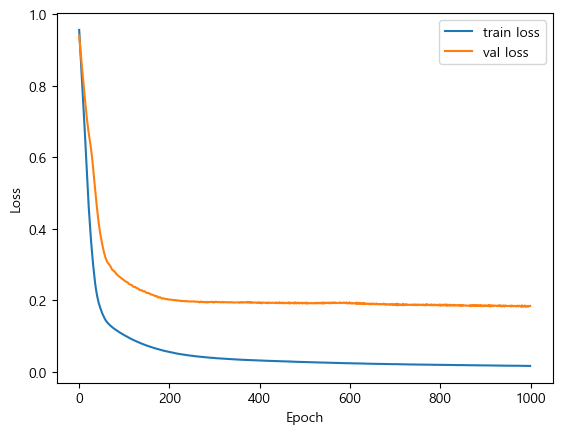

In [104]:
# 학습 도중 저정한 평가 지표 시각화
plt.plot(range(epochs), train_loss_list, label="train loss")
plt.plot(range(epochs), val_loss_list, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [108]:
# 테스트세트로 최종 검증

boston_model.eval() # 검증, 평가, 추론하는 모델에 설정
test_loss = 0.0
with torch.no_grad():
    for X_test, y_test in test_loader_boston:
        # 1. X, y를 device로 이동
        X_test, y_test = X_test.to(device), y_test.to(device)
        #2. 추론
        pred_test = boston_model(X_test)
        #3. 검증 - 평가지표 계산(회귀: MSE)
        test_loss +=loss_fn(pred_test, y_test).item()
test_loss /= len(test_loader_boston) # test_loss 평균

print("최종평가:",test_loss)


최종평가: 0.18381285667419434


In [126]:
# @torch.no_grad() # 이 함수는 grad를 계산할 필요가 없는 함수임을 선언 with torch.no_grad():이 필요없음
def test(model, dataloader):
    model.eval() # 검증, 평가, 추론하는 모델에 설정
    test_loss = 0.0
    with torch.no_grad():
        for X_test, y_test in dataloader:
            # 1. X, y를 device로 이동
            X_test, y_test = X_test.to(device), y_test.to(device)
            #2. 추론
            pred_test = model(X_test)
            #3. 검증 - 평가지표 계산(회귀: MSE)
            test_loss +=loss_fn(pred_test, y_test).item()
    test_loss /= len(dataloader) # test_loss 평균
    print("최종평가:", test_loss)

In [127]:
test(boston_model, train_loader_boston)

최종평가: 0.01635867077857256


In [128]:
# 모델 저장
## 파라미터만 저장 모델 전체를 저장
save_path = "models/boston_model.pt"
torch.save(boston_model, save_path)


In [129]:
# 모델 로드
load_boston_model = torch.load(save_path, weights_only=False)
load_boston_model = load_boston_model.to(device)
summary(load_boston_model, (100, 13), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [130]:
test(load_boston_model, test_loader_boston)

최종평가: 0.18381285667419434


## 2.2 분류 (Classification)

### 2.2.1 Fashion MNIST Dataset - **다중분류(Multi-Class Classification) 문제**

10개의 범주(category)와 70,000개의 흑백 이미지로 구성된 [패션 MNIST](https://github.com/zalandoresearch/fashion-mnist) 데이터셋.
이미지는 해상도(28x28 픽셀)가 낮고 다음처럼 개별 의류 품목을 나타낸다:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>그림</b> <a href="https://github.com/zalandoresearch/fashion-mnist">패션-MNIST 샘플</a> (Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

- **Feature**이미지는 28x28 크기이며 Gray scale이다.
- **Target**은 총 10개의 class로 구성되어 있으며 각 class의 class 이름은 다음과 같다.

| 레이블 | 클래스       |
|--------|--------------|
| 0      | T-shirt/top |
| 1      | Trousers    |
| 2      | Pullover    |
| 3      | Dress       |
| 4      | Coat        |
| 5      | Sandal      |
| 6      | Shirt       |
| 7      | Sneaker     |
| 8      | Bag         |
| 9      | Ankle boot  |

> #### 학습 도중 모델 저장
>
> - 학습 도중 가장 좋은 성능을 보이는 모델이 나올 수 있다.
> - 학습 도중 모델을 저장하는 방법
>   1. 각 에폭이 끝날 때 마다 모델을 저장한다.
>   2. 한 에폭 학습 후 성능 개선이 있으면 모델을 저장하여 가장 성능 좋은 모델만 저장되도록 한다.
>      - 최고 성능 점수(best score)와 현재 에폭의 성능을 비교하여, 성능이 개선되었을 경우 모델을 저장(덮어쓰기)한다.
>
> #### 조기 종료(Early Stopping)
>
> - 학습 도중 성능 개선이 나타나지 않으면, 중간에 학습을 종료하도록 구현한다.
> - 에폭 수를 충분히 길게 설정한 뒤, 특정 횟수 동안 성능 개선이 없으면 학습을 조기 종료하도록 구현한다.
>
>\* 특정회수 10회 정도


In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

epochs = 100
batch_size = 200
learning_rate = 0.001

cpu


In [32]:
f_trainset = datasets.FashionMNIST(
    root = "datasets", train=True, download=True
)
f_testset = datasets.FashionMNIST(
    root = "datasets", train=False, download=True
)

len(f_trainset), len(f_testset)


(60000, 10000)

In [33]:
f_trainset[0]

(<PIL.Image.Image image mode=L size=28x28>, 9)

In [34]:
f_trainset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [35]:
import random
idx = random.randint(0, 60000)
print(f_trainset[idx][1], f_trainset.classes[f_trainset[idx][1]])
# f_trainset[idx][0]

1 Trouser


In [36]:
f_trainset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [37]:
f_trainset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [38]:
# 데이터세트 생성 + 전처리

f_trainset = datasets.FashionMNIST(
    root = "datasets", train=True, download=True, transform=transforms.ToTensor()
)
f_testset = datasets.FashionMNIST(
    root = "datasets", train=False, download=True, transform=transforms.ToTensor()
)
f_trainset, f_validset = random_split(f_trainset, [50000, 10000])



print(len(f_trainset), len(f_testset), len(f_validset))

f_train_loader = DataLoader(f_trainset, batch_size=batch_size, shuffle=True, drop_last=True)
f_test_loader = DataLoader(f_testset, batch_size=batch_size)
f_valid_loader = DataLoader(f_validset, batch_size=batch_size)

print(len(f_train_loader),len(f_test_loader), len(f_valid_loader) )

50000 10000 10000
250 50 50


In [39]:
class FashionMNISTNodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(28*28, 512)
        self.lr2 = nn.Linear(512, 256)
        self.lr3 = nn.Linear(256, 128)
        self.lr4 = nn.Linear(128, 64)
        self.lr5 = nn.Linear(64, 32)
        # 출력층 - out_features개수 정답이 class일 확률을 계산할 때 사용 값(logit)
        self.lr6 = nn.Linear(32, 10)
        # 활성함수 ReLU
        self.relu = nn.ReLU()

    def forward(self, X):
        # X: (1, 28, 28) -> 1차원(1*28*28, ) ->Linear
        out = nn.Flatten()(X) # callabe 0축은 놔두고 1번축부터 flatten한다.

        # 선형(Linear) -> 비선형(ReLUI)
        out = self.lr1(out)
        out = self.relu(out)

        out = self.lr2(out)
        out = self.relu(out)
        
        out = self.lr3(out)
        out = self.relu(out)
        
        out = self.lr4(out)
        out = self.relu(out)
        
        out = self.lr5(out)
        out = self.relu(out)
        
        output = self.lr6(out)
        return output

In [40]:
f_model = FashionMNISTNodel().to(device)
print(f_model)
summary(f_model, (batch_size, 1, 28, 28), device=device)

FashionMNISTNodel(
  (lr1): Linear(in_features=784, out_features=512, bias=True)
  (lr2): Linear(in_features=512, out_features=256, bias=True)
  (lr3): Linear(in_features=256, out_features=128, bias=True)
  (lr4): Linear(in_features=128, out_features=64, bias=True)
  (lr5): Linear(in_features=64, out_features=32, bias=True)
  (lr6): Linear(in_features=32, out_features=10, bias=True)
  (relu): ReLU()
)


Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTNodel                        [200, 10]                 --
├─Linear: 1-1                            [200, 512]                401,920
├─ReLU: 1-2                              [200, 512]                --
├─Linear: 1-3                            [200, 256]                131,328
├─ReLU: 1-4                              [200, 256]                --
├─Linear: 1-5                            [200, 128]                32,896
├─ReLU: 1-6                              [200, 128]                --
├─Linear: 1-7                            [200, 64]                 8,256
├─ReLU: 1-8                              [200, 64]                 --
├─Linear: 1-9                            [200, 32]                 2,080
├─ReLU: 1-10                             [200, 32]                 --
├─Linear: 1-11                           [200, 10]                 330
Total params: 576,810
Trainable params: 576,810
Non-trainable pa

In [41]:
# loss 함수 - 자중분류: CrossEntropyLoss() 모델이 예측한 값: softmax(), (정답): OneHotEncording 변환 후 loss 계산
loss_fn = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(f_model.parameters(), lr=learning_rate)

In [46]:
@torch.no_grad()
def f_mnist_test(model, dataloader, device=device):
    """평가함수 - loss와 accuracy 계산해서 반환"""
    model.eval.to(device)
    model.eval()

    loss = 0.0
    acc =0.0

    for X, y in dataloader:
        # 1. X, y를 device로 이동
        X, y = X.to(device), y.to(device)
        # 2. 추론
        pred = model(X) # pred: class별 logit(확률계산전값)
        pred_label = torch.argmax(pred, dim=-1) # pred.shape:(batch, 10) -> pred_label (batch, 1)



        #3. 검증/평가(loss, accruacy)
        loss = loss_fn(pred, y).item()
        acc += torch.suim(pred_label == y).item()

    loss /= len(dataloader) # loss/누적횟수 = 평균
    acc/= len(dataloader.dataset)
    return loss, acc # {"loss": loss, "accuracy": acc}
    

    


In [50]:
# 학습
import time

train_loss_list = []
val_loss_list = []
val_acc_list = []

# 학습 중 성능이 개선이 되면 모델을 저장
# 지정한 epoich 동안 성능이 개선되지 않으면 학습을 중지(early stopping)

best_score = torch.inf # 성는 개선 여부를 validation loss로 모니터링, 시작은 제일 큰 수로 지정(무한)
saved_models_path = "saved_models/fashion_mnist_model.pth" # 성능이 개ㅑ선된 epoch의 모델을 저장할 경로

# 조기 종료
patience = 10 # 몇 epoch 동안 성능 개선ㅁ을 확인할 지.
stop_count = 0 # 성능 개선이 안될 때 몇번째 학습중인지 저장할 변수 patience == stop_count 종료

s = time.time()
for epoch in range(epochs):
    # train
    f_model.train()
    train_loss = 0.0
    for X_train, y_train in f_train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)

        pred_train = f_model(X_train)

        loss_train = loss_fn(pred_train, y_train)

        loss_train.backward()

        optimizer.step()

        optimizer.zero_grad()

        train_loss += loss_train.item()

# 1 epoch 학습한 loss를 계산(평균)
train_loss /= len(f_train_loader)
train_loss_list.append(train_loss)

    ###########
    # validation
    ##########
f_model.eval()
val_loss, val_acc = f_mnist_test(model=f_model, datalboader=f_valid_loader, device=device)
  
val_loss_list.append(val_loss)
val_acc_list.append(val_acc)
# 현재 epoch 학습 결과 로그 출력
print(f"[{epoch+1}/{epochs}] train loss: {train_loss}, val loss: {val_loss}, val acc: {val_acc}")

########## 성능 개선 시 모델 저정 성능이 개선이 없으면 조기종료 처리
# 성능: validation loss 기준 (작을수록 좋은 성능)
if val_loss < best_score: # 성능개선
    # 
    torch.save(f_model, saved_models_path)
    print(f">>>>> {epoch+1}에소 모델저장-이전 score: {best_score}, 개선된 score: {val_loss}")
    best_score = val_loss
    # stop_count르ㅜㄹ 초기화
    stop_count = 0

else: # 성능 개선이 안됨
    stop_count += 1
    if patience == stop_count:
        print(f">>>>> 학습을 조기종료합니다. val loss가 {best_score}애소 개선되지 않음")
        break

e = time.time()
print("거린시가냐초):", e-s)






KeyboardInterrupt: 

In [ ]:
import pandas as pd
train_result = pd.DataFrame({
    "train loss": train_loss_list,
    "valid loss": val_loss_list,
    "val accuracy": val_acc_list
})
train_result.rename_axis(index="Epoch", inplace=True)


In [51]:
train_result[["train loss", "valid loss"]].plot(ylabel="Loss")

NameError: name 'train_result' is not defined

In [52]:
train_result["val accuracy"].plot(ylabel="Loss")

NameError: name 'train_result' is not defined

In [9]:
f_trainset[0]

(tensor([[[0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000,
           0.1882, 0.8392, 0.5529, 0.4392, 0.3098, 0.2118, 0.1294, 0.2275,
           0.2784, 0.3412, 0.8314, 0.6118, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0392, 0.6039,
           1.0000, 0.9333, 0.9569, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
           1.0000, 1.0000, 0.9098, 0.9412, 0.8627, 0.1922, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3647, 0.9333, 0.9725,
           0.9020, 0.9059, 0.8667, 0.8627, 0.8824, 0.8863, 0.8980, 0.8980,
           0.8667, 0.8549, 0.9098, 0.8941, 0.9451, 0.9765, 0.8588, 0.0000,
           0.0000, 0.0157, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0078, 0.0000, 0.0275, 0.8980, 0.9255, 0.8863,
           0.9294, 0.9176, 0.9098, 0.9216, 0.9137, 0.9020, 0.9020, 0.9098,
           0.9098, 0.9098, 0.9059, 0.9137, 

In [ ]:
# 저장된 모델(best model) load 후 최종 테스트
f_load_model = torch.load(saved_models_path, weights_only=False)
f_load_model

FileNotFoundError: [Errno 2] No such file or directory: 'saved_models/fashion_mnist_model.pth'

In [ ]:
test_loss, test_acc = f_mnist_test(
    model=f_load_model, dataloader=f_test_loader, device=device
)

In [54]:
print(test_loss, test_acc)

NameError: name 'test_loss' is not defined

In [57]:
x, y = f_testset[0]
x.shape
x = x.unsqueeze(dim=0)
print(x.shape)

torch.Size([1, 1, 28, 28])


In [58]:
with torch.no_grad():
    p = f_load_model(x)

NameError: name 'f_load_model' is not defined

In [59]:
p

NameError: name 'p' is not defined

In [61]:
# 9가 정답, 정답 class
p.argmax(dim=-1)

NameError: name 'p' is not defined

In [65]:
# 정답 확률
proba = p.softmax(dim=-1)
proba
proba.sum()
proba("확률:", m.values, "label:", m.indices)
p.max(dim=-1).values

NameError: name 'p' is not defined

In [68]:
f_testset.classes[m.indices.item()]

NameError: name 'm' is not defined

In [69]:
x0 = f_trainset[0][0]
type(x0)

torch.Tensor

인터넷사진 -> grays.cale, -> resize 28*28 형태를 맞춰줘여ㅑ 됨

### 2.2.2 위스콘신 유방암 데이터셋 - **이진분류(Binary Classification) 문제**

-   **이진 분류 문제 처리 모델의 두가지 방법**
    1. positive(1)일 확률을 출력하도록 구현
        - output layer: units=1, activation='sigmoid'
        - loss: binary_crossentropy
    2. negative(0)일 확률과 positive(1)일 확률을 출력하도록 구현 => 다중분류 처리 방식으로 해결
        - output layer: units=2, activation='softmax', y(정답)은 one hot encoding 처리
        - loss: categorical_crossentropy
-   위스콘신 대학교에서 제공한 종양의 악성/양성여부 분류를 위한 데이터셋
-   Feature
    -   종양에 대한 다양한 측정값들
-   Target의 class
    -   0 - malignant(악성종양)
    -   1 - benign(양성종양)


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [2]:
# Dataset
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

y = y.reshape(-1, 1)
print("reshape 후:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=0)

(569, 30) (569,)
reshape 후: (569, 1)


In [3]:
# 전처리
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Dataset
## 모델의 weight, bias -> float32. X, y는 weight, bias와 계산을 하게 되기 때문에 타입을 맞춰준다.
trainset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),  
    torch.tensor(y_train, dtype=torch.float32)
)
testset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32)
)

In [5]:
# class name <-> class index
classes = np.array(["악성종양", "양성종양"])
class_to_idx = {"악성종양":0, "양성종양":1}

trainset.classes = classes
trainset.class_to_idx = class_to_idx

testset.classes = classes
testset.class_to_idx = class_to_idx

In [6]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=200, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size=100)

In [7]:
######### 모델 정의
class BCModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(30, 16)
        self.lr2 = nn.Linear(16, 8)
        # 출력층 - out_feature: 1 - 양성(positive)일 확률을 출력
        self.lr3 = nn.Linear(8, 1)
        # 은닉층 활성함수
        self.relu = nn.ReLU()
        # 출력층 활성함수
        self.sigmoid = nn.Sigmoid()

        



    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)
        out = self.lr2(out)
        out = self.relu(out)
        out = self.lr3(out)
        out = self.sigmoid(out)
        return output


In [ ]:
######### 학습
from torchinfo import summary

bc_model = BCModel().to(device)
print(bc_model)
summary(bc_model, (100, 30), device=device)


BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Linear: 1, ReLU: 1, Linear: 1, ReLU: 1, Linear: 1, Sigmoid: 1]

In [9]:
loss_fn = nn.BCELoss
optimizer = torch.optim.Adam(bc_model.parameters(), lr=0.01)

In [ ]:
# 학습 성응(val loss) 개선시 저장 조기종료
epochs = 1000
patience = 10
stop_count = 0
best_score = torch.inf

train_loss_list = []
val_loss_list = []
val_acc_list = []

saved_bc_model_path = "saved_models/bc_model.pth"

for epoch in range(epochs):
    bc_model.train()
    train_loss = 0.0
    for X_train, y_train, in train_loader:
        # 1. 이동
        X_train, y_train = X_train.to(device), y_train.to(device)

        # 2. 추론
        pred_train = bc_model(X_train)

        # 3. loss 계산
        loss_train = loss_fn(pred_train, y_train)

        # 4. grad 계산
        loss_train.backward()

        # 5. 파라미터 업데이트
        optimizer.step()

        # 6. grad 초기화
        optimizer.zero_grad()

        # 7. train loss 누적
        train_loss += loss_train.item()

    # train loss 계산
    train_loss /= len(f_train_loader)
    train_loss_list.append(train_loss)      



    bc_model.eval()
    valid_loss = 0.0
    valid_loss = 0.0

    valid_loss, valid_acc = bc_test(
        model=bc_model, dataloader=test_loader, loss_fn=loss_fn, device=device
    )
    val_loss_list.append(valid_loss)
    val_acc_list.append(valid_acc)

    print(f"[{epoch+1}/{epochs}] train loss: {train_loss}, val loss: {valid_loss}, va; acc: {valid_acc}")

    if valid_loss < best_score:
        torch.save(bc_model, save_bc_model_path)
        print(f"{epoch+1}에서 저장, {best_score} -> {valid_loss}")
        stop_count = 0
    else:
        stop_count += 1
        if patience == stop_count:
            print(f">>>>>{epoch}에폭에서 조기종료")
            break











ValueError: training mode is expected to be boolean

In [14]:
a = torch.tensor([[True], [True], [False]])

In [15]:
def bc_test(model, dataloader, loss_fn, device="cpu"):
    model = model.to(device)
    model.eval()

    loss = 0.0
    accuracy = 0.0

    for X, y in dataloader:
        # 1. 이동
        X, y = X.to(device), y.to(device)

        # 2. 추론
        pred = model(X)
        pred_label = (pred > 0.5).type(torch.int32) # 붍타입 텐서의 타입을 인트32로 변환 트루1, 폴스0
  
        # 3. 검증(loss, acc)
        loss += loss_fn(pred, y).item()
        accuracy += torch,sum(pred_label == y).item()
        
    loss /= len(dataloader)
    accuracy /= len(dataloader.dataset)
    return loss, accuracy

    



In [ ]:
######### 저장된 모델 로드

load_bc_model +torch.load(saved_bc_model_path, weights_only=False)
load_bc_model



In [ ]:
###### 추론 함수 #######
def predict_bc(model, X, device="cpu"):
    # model로 X를 추론한 결과를 반환
    # label, 확률
    
    model = model.to(device)
    X = X.to(device)
    model.eval()

    result = []
    with torch.no_grad():
        pred_proba = model(X)
        pred_class = (pred_proba > 0.5).type(torch.int32)
        for class_index, proba in zip(pred_class, pred_proba):
            # print(class_index, proba if class_index.item() == 1 else 1-proba)
            result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
        return result

In [ ]:
new_data = torch.tensor(X_test_scaled[:5], dtype=torch.float32)
result = predict_bc(load_bc_model, new_data, device)



In [17]:
result

NameError: name 'result' is not defined

In [19]:
print(y_test[:5])

[[1]
 [0]
 [0]
 [1]
 [0]]


# 3. 모델 유형별 구현 정리

## 3.1 공통

-   Input layer(첫번째 Layer)의 in_features
    -   입력데이터의 feature(속성) 개수에 맞춰준다.
-   Hidden layer 수
    -   경험적(art)으로 정한다.
    -   Hidden layer에 Linear를 사용하는 경우 보통 feature 수를 줄여 나간다. (핵심 특성들을 추출해나가는 과정의 개념.)

## 3.2 회귀 모델

-   output layer의 출력 unit개수(out_features)
    -   정답의 개수
    -   ex
        -   집값: 1
        -   아파트가격, 단독가격, 빌라가격: 3 => y의 개수에 맞춘다.
-   출력 Layer에 적용하는 activation 함수
    -   일반적으로 **None**
    -   값의 범위가 설정되 있고 그 범위의 값을 출력하는 함수가 있을 경우
        -   ex) 0 ~ 1: logistic(Sigmoid), -1 ~ 1: hyperbolic tangent(Tanh)
-   loss함수
    -   MSELoss
-   평가지표
    -   MSE, RMSE, R square($R^2$)

## 3.3 다중분류 모델

-   output layer의 unit 개수
    -   정답 class(고유값)의 개수
-   출력 Layer에 적용하는 activation 함수
    -   Softmax: 클래스별 확률을 출력
-   loss함수
    -   **categrocial crossentropy**
    -   파이토치 함수
        -   **CrossEntropyLoss** = NLLLoss(정답) + LogSoftmax(모델 예측값)
        -   **NLLLoss**
            -   정답을 OneHot Encoding 처리 후 Loss를 계산한다.
            -   입력으로 LogSoftmax 처리한 모델 예측값과 onehot encoding 안 된 정답을 받는다.
        -   **LogSoftmax**
            -   입력값에 Softmax 계산후 그 Log를 계산한다.
                -   NLLLoss의 모델 예측값 입력값으로 처리할 때 사용한다.

```python
pred = model(input)
loss1 = nn.NLLLoss(nn.LogSoftmax(dim=-1)(pred), y)
# or
loss2 = nn.CrossEntropyLoss()(pred, y)
```

## 3.4 이진분류 모델

-   output layer의 unit 개수
    -   1개 (positive일 확률)
-   출력 Layer에 적용하는 activation 함수
    -   Sigmoid(Logistic)
-   loss 함수
    -   **Binary crossentropy**
    -   파이토치 함수: **BCELoss**
